In [6]:
import kagglehub
import pandas as pd
import numpy as np
import os

try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'))
    print(" Path to dataset files:", path)
    
except Exception as e:
    print(f"Something failed... {e}")

data.head()

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]

data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data = data.drop(columns=columns_drop, errors='ignore')

X = data.drop('Label', axis=1)
y = data['Label']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    xgb = XGBClassifier(eval_metric='mlogloss', random_state=1)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)
    print('-Fold--')
    print(classification_report(y_test, y_pred))

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25459
           1       1.00      1.00      1.00     31761

    accuracy                           1.00     57220
   macro avg       1.00      1.00      1.00     57220
weighted avg       1.00      1.00      1.00     57220

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25459
           1       1.00      1.00      1.00     31760

    accuracy                           1.00     57219
   macro avg       1.00      1.00      1.00     57219
weighted avg       1.00      1.00      1.00     57219

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25458
           1       1.00      1.00      1.00     31761

    accuracy                           1.00     57219
   macro avg       1.00      1.00      1.00     57219
weighted avg       1.00      1.00      1.00     57

2
1.0
[3.43660562e-04 1.52923178e-03 7.40367628e-04 9.66682092e-06
 8.27528298e-01 6.77592121e-03 5.17957960e-04 1.02462574e-04
 3.30760558e-05 2.80535663e-04 1.30632770e-05 0.00000000e+00
 2.32052887e-04 1.10689574e-03 1.32561326e-01 5.67522715e-04
 2.75264401e-03 2.03356473e-03 1.05087704e-04 4.35091570e-05
 8.32428123e-05 7.60293842e-05 5.98847837e-05 1.19735960e-05
 5.91447519e-04 3.19368119e-04 3.39897675e-03 1.47444138e-04
 6.66622189e-04 9.52280097e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 3.17382603e-03 1.17788673e-04
 4.68754821e-04 4.58569266e-03 1.62274068e-06 8.13617953e-04
 1.47310505e-03 3.92017755e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.57906993e-04 2.91613629e-03 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.15704385e-05 1.48545019e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.42878352e-03
 9.90074113e-05 4.

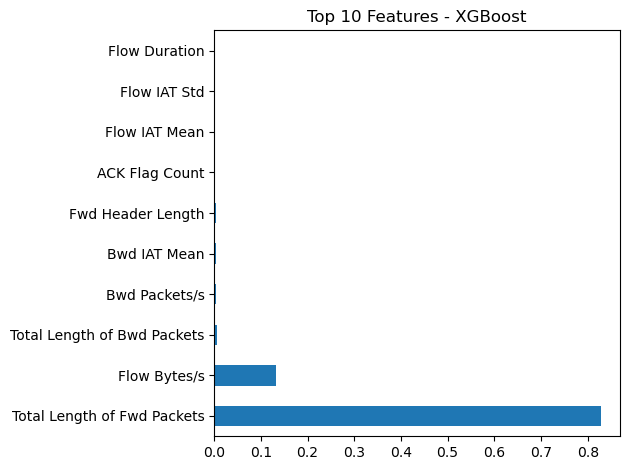

In [10]:
import matplotlib.pyplot as plt

xgb_importance = XGBClassifier(eval_metric='mlogloss', random_state=1)
xgb_importance.fit(X,y)


print(xgb_importance.n_classes_)
print(xgb_importance.feature_importances_.sum())
print(xgb_importance.feature_importances_)

importance = pd.Series(xgb_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - XGBoost')
plt.tight_layout()
plt.show()